# Test package *social_graph*

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from social_graph.preprocessing import PROFESSION_MAP, load_data_and_describe_network, create_graph, check_profession_with_map, map_professions, create_persona_df, create_persona_features_df, search_best_number_of_personae, create_personae
from social_graph.describe import describe_personae, persona_significance
from social_graph.metrics import cramers_v_matrix, calculate_global_metrics, calculate_local_metrics, statistical_difference_check

## Data loading

In [2]:
# database connection
conn = sqlite3.connect("data/database_server_FRS.db")

In [3]:
users, follow, posts = load_data_and_describe_network(conn)

Number of users: 1000
Total actions: 20659
Follow actions: 15716
Unfollow actions: 4943
Number of rounds: 102
Number of posts: 459919



## Create persona

In [4]:
profession_not_in_map = check_profession_with_map(users)

Number of professions not in map: 0
Professions: set()


If there are some profession then update map. Otherwise, there is option 'Alternative' in map.

In [5]:
feature_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism', 'age', 'profession']

In [6]:
personae = create_persona_df(users)
personae.head()

,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level
1,13,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,resilient/confident,old,Science_Academia,female,democrat,high school
2,2,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,middle,Sport,female,democrat,high school
3,9,inventive/curious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,young,Law_Finance_Admin,male,democrat,high school
4,3,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,high school
5,4,inventive/curious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Retail_Service,male,democrat,high school


In [7]:
features_df = create_persona_features_df(personae, feature_cols)
features_df.head()

Features encoded size: (1000, 25)


,openness_consistent/cautious,openness_inventive/curious,conscientiousness_efficient/organized,conscientiousness_extravagant/careless,extroversion_outgoing/energetic,extroversion_solitary/reserved,agreeableness_critical/judgmental,agreeableness_friendly/compassionate,neuroticism_resilient/confident,neuroticism_sensitive/nervous,...,profession_Arts_Media,profession_Healthcare,profession_Law_Finance_Admin,profession_Retail_Service,profession_Science_Academia,profession_Security,profession_Skilled_Trades,profession_Sport,profession_Technology,profession_Transport
1,True,False,False,True,False,True,False,True,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
3,False,True,False,True,False,True,False,True,False,True,...,False,False,True,False,False,False,False,False,False,False
4,False,True,True,False,False,True,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
5,False,True,True,False,False,True,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False


k=2 silhouette=0.0847
k=3 silhouette=0.1027
k=4 silhouette=0.0991
k=5 silhouette=0.0962
k=6 silhouette=0.0971
k=7 silhouette=0.1082
k=8 silhouette=0.1162
k=9 silhouette=0.1218


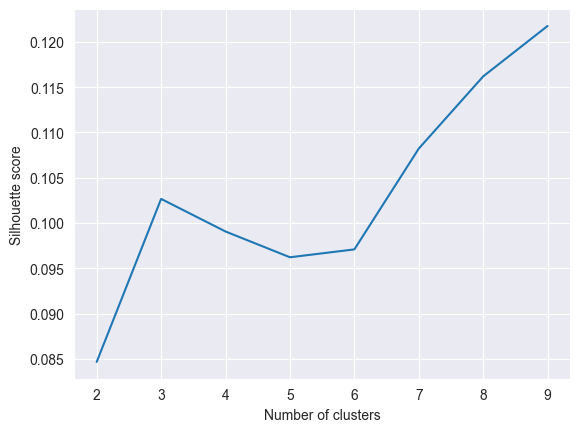

In [8]:
search_best_number_of_personae(features_df)

In [9]:
k_best = 4

personae = create_personae(k_best, personae, features_df)
personae.head()

persona
Persona_2    264
Persona_1    258
Persona_0    246
Persona_3    232
Name: count, dtype: int64


,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
1,13,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,resilient/confident,old,Science_Academia,female,democrat,high school,Persona_2
2,2,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,middle,Sport,female,democrat,high school,Persona_2
3,9,inventive/curious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,young,Law_Finance_Admin,male,democrat,high school,Persona_2
4,3,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,high school,Persona_2
5,4,inventive/curious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Retail_Service,male,democrat,high school,Persona_2


In [10]:
description = describe_personae(personae, feature_cols)
description.head()

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous,...,Arts_Media,Healthcare,Law_Finance_Admin,Retail_Service,Science_Academia,Security,Skilled_Trades,Sport,Technology,Transport
persona,,,,,,,,,,,,,,,,,,,,,
Persona_0,0.373984,0.626016,0.512195,0.487805,0.0,1.0,0.699187,0.300813,0.658537,0.341463,...,0.134146,0.024390,0.097561,0.191057,0.219512,0.052846,0.097561,0.032520,0.065041,0.040650
Persona_1,0.500000,0.500000,0.736434,0.263566,1.0,0.0,0.755814,0.244186,0.224806,0.775194,...,0.100775,0.046512,0.096899,0.135659,0.279070,0.062016,0.065891,0.046512,0.085271,0.027132
Persona_2,0.693182,0.306818,0.507576,0.492424,0.0,1.0,0.352273,0.647727,0.378788,0.621212,...,0.075758,0.037879,0.125000,0.143939,0.318182,0.045455,0.064394,0.060606,0.053030,0.030303
Persona_3,0.474138,0.525862,0.258621,0.741379,1.0,0.0,0.232759,0.767241,0.775862,0.224138,...,0.133621,0.021552,0.099138,0.112069,0.232759,0.056034,0.099138,0.025862,0.112069,0.064655


In [11]:
persona_significance(personae, feature_cols)

Features significance regarding personae:
openness: 7.159452090705436e-12
conscientiousness: 4.9399776679685234e-24
extroversion: 1.7994208765314067e-216
agreeableness: 4.446319136588006e-42
neuroticism: 9.925290669892721e-41
age: 2.241907079515382e-41
profession: 0.08613787110389373


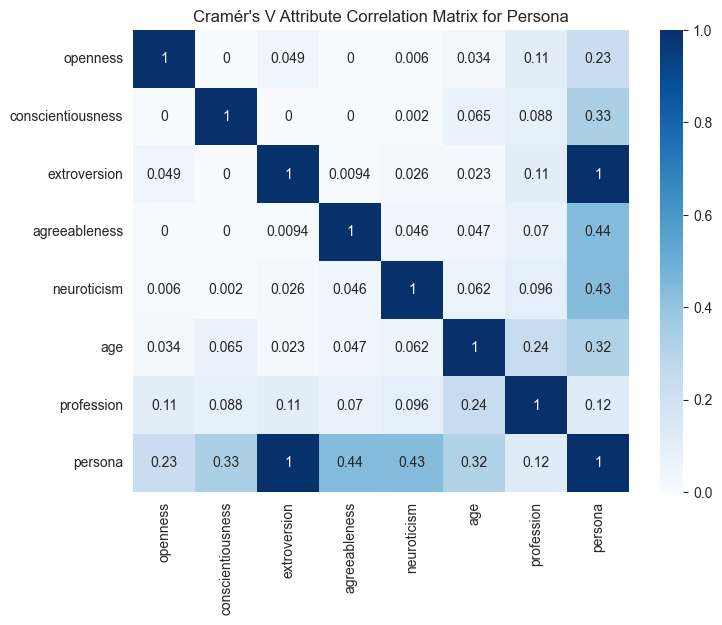

In [12]:
cv_matrix = cramers_v_matrix(personae[feature_cols+['persona']], label='Persona')

## Build graph and check connective components

In [13]:
G_follow, G_follow_lcc = create_graph(follow)

Number of nodes: 945
Number of edges: 13304
Number of connective components: 2
Components sizes: [943, 2]
Number of nodes (LCC): 943
Number of edges (LCC): 13303


In [14]:
# mapping
persona_dict = personae.set_index('id')['persona'].to_dict()

# add attributes to nodes
nx.set_node_attributes(G_follow, persona_dict, "persona")
nx.set_node_attributes(G_follow_lcc, persona_dict, "persona")

# check
for node in list(G_follow.nodes())[:5]:
    print(node, G_follow.nodes[node])

171 {'persona': 'Persona_0'}
673 {'persona': 'Persona_1'}
485 {'persona': 'Persona_0'}
907 {'persona': 'Persona_3'}
74 {'persona': 'Persona_1'}


## Metrics

In [15]:
calculate_global_metrics(G_follow, G_follow_lcc)

Mean degree: 28.16
Density: 0.0149
Diameter: 6
Avg. shortest path: 2.639
Modularity score: 0.140
Persona assortativity: -0.0006259832931752655


,Metric,Simulation
0,Mean degree,28.156614
1,Density,0.014913
2,Diameter,6.000000
3,Avg. shortest path,2.639210
4,Modularity,0.139957
5,Persona assortativity,-0.000626


In [16]:
local_metrics, summary = calculate_local_metrics(G_follow_lcc)
summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,
Persona_0,233,14.497854,15.626609,30.124464,0.001725,0.000094,0.001075,13.849785,1.014146
Persona_1,243,13.967078,13.646091,27.613169,0.001712,0.000118,0.001063,13.156379,1.002560
Persona_2,246,14.093496,14.056911,28.150407,0.001870,0.000075,0.001057,12.113821,0.996377
Persona_3,221,13.864253,13.067873,26.932127,0.001640,0.000102,0.001046,12.470588,0.986304


In [17]:
statistical_difference_check(local_metrics)

in_degree statistics: p = 0.6120
out_degree statistics: p = 0.5838
total_degree statistics: p = 0.7755
betweenness statistics: p = 0.6726
eigenvector statistics: p = 0.5507
pagerank statistics: p = 0.6368
kcore statistics: p = 0.6836


## Pipeline test

In [18]:
from social_graph.pipeline import *

Data loading ...

Number of users: 1000
Total actions: 20659
Follow actions: 15716
Unfollow actions: 4943
Number of rounds: 102
Number of posts: 459919

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 25)

Searching best number of persona ...

k=2 silhouette=0.0847
k=3 silhouette=0.1027
k=4 silhouette=0.0991
k=5 silhouette=0.0962
k=6 silhouette=0.0971
k=7 silhouette=0.1082
k=8 silhouette=0.1162
k=9 silhouette=0.1218


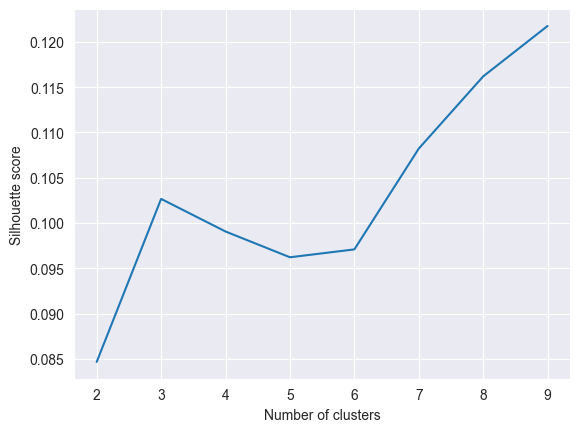


Done!


In [19]:
personae, features_df, follow = run_simulation_preprocessing(conn)

Persona creation ...

persona
Persona_1    239
Persona_4    210
Persona_3    200
Persona_2    180
Persona_0    171
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 1.838799060377571e-36
conscientiousness: 8.829906340240813e-98
extroversion: 3.592807398138545e-161
agreeableness: 9.275936021836037e-46
neuroticism: 2.4190340502376113e-37
age: 5.7312687161557725e-39
profession: 0.0014043344531023186


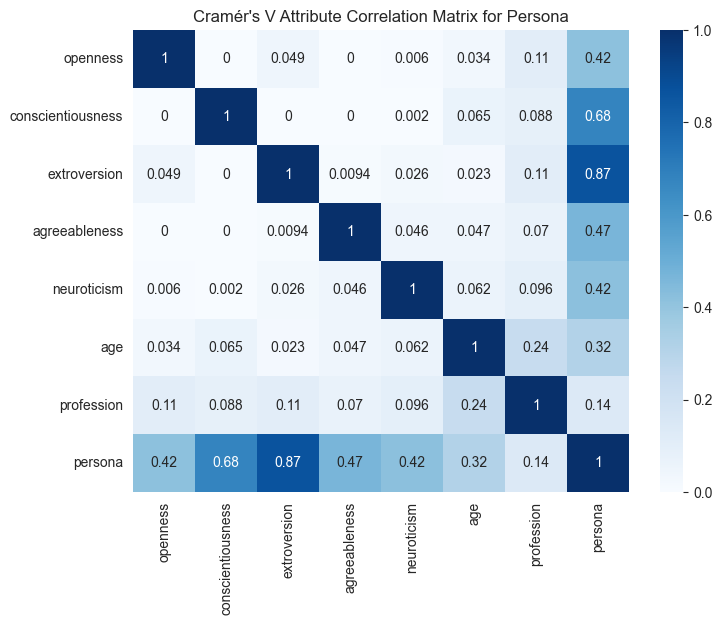

In [20]:
k_best = 5

description, persona_dict = cluster_persona_and_analyse(personae, features_df, k_best)

In [21]:
global_metrics, summary = build_graph_and_analyse(follow, persona_dict)

Graph creation ...

Number of nodes: 945
Number of edges: 13304
Number of connective components: 2
Components sizes: [943, 2]
Number of nodes (LCC): 943
Number of edges (LCC): 13303

Global metrics ...

Mean degree: 28.16
Density: 0.0149
Diameter: 6
Avg. shortest path: 2.639
Modularity score: 0.138
Persona assortativity: 0.00019154711738170237

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.7879
out_degree statistics: p = 0.9872
total_degree statistics: p = 0.9650
betweenness statistics: p = 0.9145
eigenvector statistics: p = 0.9801
pagerank statistics: p = 0.7705
kcore statistics: p = 0.9796


In [22]:
global_metrics

,Metric,Simulation
0,Mean degree,28.156614
1,Density,0.014913
2,Diameter,6.000000
3,Avg. shortest path,2.639210
4,Modularity,0.138295
5,Persona assortativity,0.000192


In [23]:
summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,
Persona_0,160,13.687500,14.331250,28.018750,0.001484,0.000067,0.001019,13.281250,0.960736
Persona_1,223,13.892377,13.309417,27.201794,0.001680,0.000117,0.001059,12.869955,0.998263
Persona_2,166,15.162651,14.409639,29.572289,0.002046,0.000084,0.001128,12.397590,1.063497
Persona_3,191,13.848168,13.120419,26.968586,0.001685,0.000123,0.001049,12.586387,0.989351
Persona_4,203,14.054187,15.487685,29.541872,0.001808,0.000081,0.001051,13.315271,0.990952
